In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DATA_DIR = '/content/drive/MyDrive/data'

TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR  = os.path.join(DATA_DIR, 'test')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

train_df = pd.read_csv(os.path.join(TRAIN_DIR, 'labels.csv'))
test_df  = pd.read_csv(os.path.join(TEST_DIR,  'labels.csv'))

print("=== Train columns ===")
print(train_df.columns.tolist())
print(train_df.head(3))

print("\n=== Test columns ===")
print(test_df.columns.tolist())
print(test_df.head(3))

=== Train columns ===
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']
   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False         True                 0   
1     10              False            True         True                14   
2     20               True            True         True                99   

   px_pedestrian  px_vehicle  
0              0          85  
1            301        1138  
2            196         517  

=== Test columns ===
['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']
   frame  has_traffic_light  has_pedestrian  has_vehicle  px_traffic_light  \
0      0              False           False        False                15   
1     10               True           False         True               299   
2     20               True           False         Tru

In [ ]:
print(f"Training images   : {len(train_df)}")
print(f"Test images       : {len(test_df)}")

train_files = os.listdir(os.path.join(TRAIN_DIR, 'rgb-front'))
test_files  = os.listdir(os.path.join(TEST_DIR,  'rgb-front'))
print(f"\nActual train files in rgb-front : {len(train_files)}")
print(f"Actual test files  in rgb-front : {len(test_files)}")

Training images   : 7200
Test images       : 3600

Actual train files in rgb-front : 7200
Actual test files  in rgb-front : 3600


In [ ]:
LABELS = ['has_pedestrian', 'has_vehicle', 'has_traffic_light']

print("=== Class distribution (Train) ===\n")
for label in LABELS:
    counts = train_df[label].value_counts().sort_index()
    total  = len(train_df)
    print(f"  {label}:")
    print(f"    False (absent) : {counts.get(False,0):5d}  ({counts.get(False,0)/total*100:.1f}%)")
    print(f"    True (present) : {counts.get(True,0):5d}  ({counts.get(True,0)/total*100:.1f}%)")
    print()

=== Class distribution (Train) ===

  has_pedestrian:
    False (absent) :  5482  (76.1%)
    True (present) :  1718  (23.9%)

  has_vehicle:
    False (absent) :  1742  (24.2%)
    True (present) :  5458  (75.8%)

  has_traffic_light:
    False (absent) :  1924  (26.7%)
    True (present) :  5276  (73.3%)



# optional bar chart


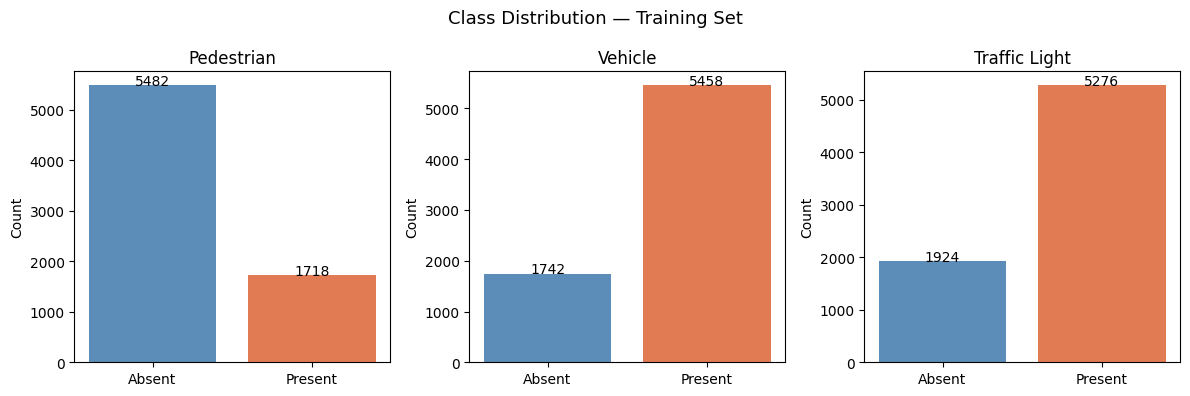

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, label in zip(axes, LABELS):
    counts = train_df[label].value_counts().sort_index()
    ax.bar(['Absent', 'Present'],
           [counts.get(False, 0), counts.get(True, 0)],
           color=['#5b8db8', '#e07b54'])
    ax.set_title(label.replace('has_', '').replace('_', ' ').title())
    ax.set_ylabel('Count')
    for i, v in enumerate([counts.get(False,0), counts.get(True,0)]):
        ax.text(i, v + 10, str(v), ha='center', fontsize=10)

plt.suptitle('Class Distribution — Training Set', fontsize=13)
plt.tight_layout()
plt.show()

Exercise 3.4 2


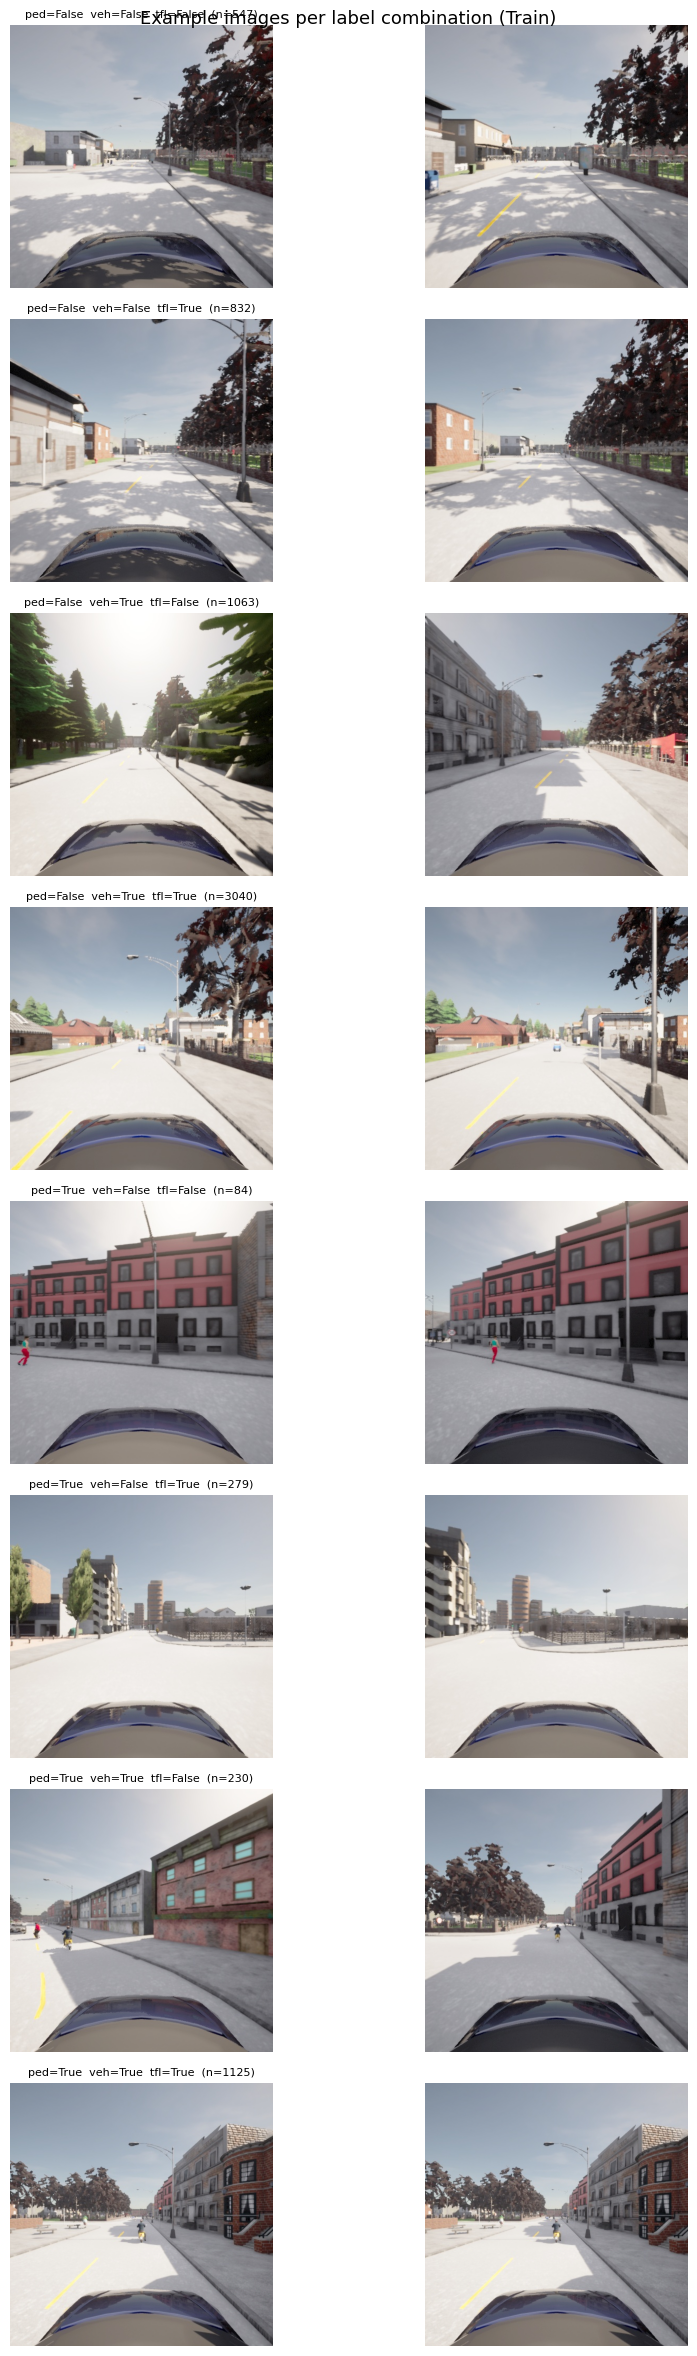

In [ ]:

from PIL import Image
import itertools
import os

IMG_DIR      = os.path.join(TRAIN_DIR, 'rgb-front')
FILENAME_COL = 'frame'
LABELS       = ['has_pedestrian', 'has_vehicle', 'has_traffic_light']

combos = list(itertools.product([False, True], repeat=3))

fig, axes = plt.subplots(len(combos), 2, figsize=(10, len(combos) * 3))

for row_idx, combo in enumerate(combos):
    ped, veh, tfl = combo
    subset = train_df[
        (train_df['has_pedestrian']    == ped) &
        (train_df['has_vehicle']       == veh) &
        (train_df['has_traffic_light'] == tfl)
    ]
    title = f"ped={ped}  veh={veh}  tfl={tfl}  (n={len(subset)})"

    for col_idx in range(2):
        ax = axes[row_idx][col_idx]
        if len(subset) > col_idx:
            sample   = subset.iloc[col_idx]
            # zero-pad to 6 digits + .jpg
            img_path = os.path.join(IMG_DIR, f"{int(sample[FILENAME_COL]):06d}.jpg")
            try:
                img = Image.open(img_path)
                ax.imshow(img)
                ax.set_title(title if col_idx == 0 else '', fontsize=8)
            except FileNotFoundError:
                ax.text(0.5, 0.5, 'Not found\n' + img_path,
                        ha='center', va='center', fontsize=7)
        else:
            ax.text(0.5, 0.5, 'No samples\nfor this combo',
                    ha='center', va='center', fontsize=8)
        ax.axis('off')

plt.suptitle('Example images per label combination (Train)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
import pandas as pd
import os
import matplotlib.pyplot as plt

In [ ]:
import shutil, os

print("Copying data to local disk.")

shutil.copytree(
    '/content/drive/MyDrive/data',
    '/content/data'
)

DATA_DIR  = '/content/data'
TRAIN_DIR = '/content/data/train'
VAL_DIR   = '/content/data/validation'

print(os.listdir('/content/data'))

Copying data to local disk... (takes 2-5 min)
Done ✓
['validation', 'train', 'test-night', 'test-fog', 'test', 'test-town-01']


In [ ]:
class CARLADataset(Dataset):
    def __init__(self, data_dir, label_col, transform=None):
        self.img_dir   = os.path.join(data_dir, 'rgb-front')
        self.labels_df = pd.read_csv(os.path.join(data_dir, 'labels.csv'))
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        row      = self.labels_df.iloc[idx]
        img_path = os.path.join(self.img_dir, f"{int(row['frame']):06d}.jpg")
        image    = Image.open(img_path).convert('RGB')
        label    = torch.tensor(float(row[self.label_col]))  # True→1.0, False→0.0

        if self.transform:
            image = self.transform(image)

        return image, label

Transforms and DataLoaders

In [ ]:

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def get_loaders(label_col, batch_size=32):
    train_ds = CARLADataset(TRAIN_DIR, label_col, transform)
    val_ds   = CARLADataset(VAL_DIR,   label_col, transform)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2,
        pin_memory=True
    )
    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )
    return train_loader, val_loader

VAL_DIR = os.path.join(DATA_DIR, 'validation')

In [ ]:
def build_model():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    #only final layer
    for param in model.parameters():
        param.requires_grad = False

    model.fc = nn.Linear(model.fc.in_features, 1)

    return model

In [ ]:
def train_model(label_col, num_epochs=15, lr=1e-3, save_dir='/content/drive/MyDrive/carla_models'):
    os.makedirs(save_dir, exist_ok=True)
    os.makedirs(os.path.join(save_dir, 'checkpoints'), exist_ok=True)

    device       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training '{label_col}' on {device}")

    train_loader, val_loader = get_loaders(label_col)

    model     = build_model().to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.fc.parameters(), lr=lr)

    train_losses, val_losses = [], []
    best_val_loss = float('inf')

    for epoch in range(num_epochs):

        # Training phase
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(images)         # forward pass
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)

        # Validation phase
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device).unsqueeze(1)
                outputs = model(images)
                loss    = criterion(outputs, labels)
                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

        # Saving  best model
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'epoch'              : epoch,
                'model_state_dict'   : model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss'           : avg_val_loss,
            }, os.path.join(save_dir, f'{label_col}_best.pth'))
            print(f" Saved best model (val_loss={avg_val_loss:.4f})")

        # Checkpoint every 5 epochs incase of server timeout
        if (epoch + 1) % 5 == 0:
            torch.save({
                'epoch'              : epoch,
                'model_state_dict'   : model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss'           : avg_val_loss,
            }, os.path.join(save_dir, f'checkpoints/{label_col}_epoch{epoch+1}.pth'))

    return train_losses, val_losses

In [ ]:
LABELS_TO_TRAIN = ['has_pedestrian', 'has_traffic_light', 'has_vehicle']

results = {}
for label in LABELS_TO_TRAIN:
    print(f"\n{'='*50}")
    print(f"  Training: {label}")
    print(f"{'='*50}")
    train_losses, val_losses = train_model(label_col=label, num_epochs=15)
    results[label] = {'train': train_losses, 'val': val_losses}


  Training: has_pedestrian
Training 'has_pedestrian' on cuda
Epoch 01/15 | Train Loss: 0.5425 | Val Loss: 0.5801
  ✓ Saved best model (val_loss=0.5801)
Epoch 02/15 | Train Loss: 0.5109 | Val Loss: 0.5857
Epoch 03/15 | Train Loss: 0.5005 | Val Loss: 0.5908
Epoch 04/15 | Train Loss: 0.4867 | Val Loss: 0.5840
Epoch 05/15 | Train Loss: 0.4818 | Val Loss: 0.6436
Epoch 06/15 | Train Loss: 0.4815 | Val Loss: 0.6011
Epoch 07/15 | Train Loss: 0.4719 | Val Loss: 0.5941
Epoch 08/15 | Train Loss: 0.4698 | Val Loss: 0.6007
Epoch 09/15 | Train Loss: 0.4666 | Val Loss: 0.5942
Epoch 10/15 | Train Loss: 0.4691 | Val Loss: 0.6087
Epoch 11/15 | Train Loss: 0.4576 | Val Loss: 0.6123
Epoch 12/15 | Train Loss: 0.4587 | Val Loss: 0.6090
Epoch 13/15 | Train Loss: 0.4561 | Val Loss: 0.6138
Epoch 14/15 | Train Loss: 0.4577 | Val Loss: 0.6039
Epoch 15/15 | Train Loss: 0.4542 | Val Loss: 0.6324

  Training: has_traffic_light
Training 'has_traffic_light' on cuda
Epoch 01/15 | Train Loss: 0.4299 | Val Loss: 0.3359

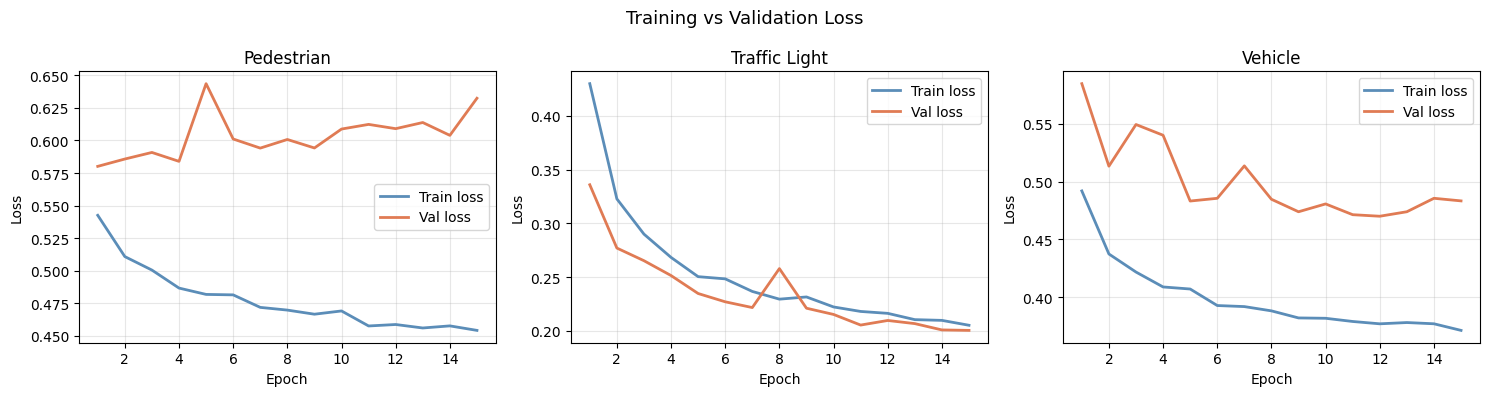

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, label in zip(axes, LABELS_TO_TRAIN):
    train_l = results[label]['train']
    val_l   = results[label]['val']
    epochs  = range(1, len(train_l) + 1)

    ax.plot(epochs, train_l, label='Train loss', color='#5b8db8', linewidth=2)
    ax.plot(epochs, val_l,   label='Val loss',   color='#e07b54', linewidth=2)
    ax.set_title(label.replace('has_', '').replace('_', ' ').title())
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training vs Validation Loss', fontsize=13)
plt.tight_layout()
plt.show()

Q3
Three separate models are safer than one multi-label classifier because:

Fault isolation — a failure or bug in the pedestrian detector doesn't affect vehicle or traffic light detection
Independent auditing — each model can be tested, certified, and updated independently without risk of regression in the others
Clearer accountability — if the AV brakes incorrectly, you can trace exactly which classifier caused it
Targeted retraining — if pedestrian detection degrades in fog, you retrain only that model without touching the others

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import torch
import numpy as np

TEST_DIR  = os.path.join(DATA_DIR, 'test')
SAVE_DIR  = '/content/drive/MyDrive/carla_models'
LABELS    = ['has_pedestrian', 'has_traffic_light', 'has_vehicle']
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def get_test_loader(label_col, batch_size=32):
    test_ds = CARLADataset(TEST_DIR, label_col, transform)
    return DataLoader(test_ds, batch_size=batch_size,
                      shuffle=False, num_workers=2, pin_memory=True)

In [ ]:
def evaluate_model(label_col):
    model      = build_model().to(device)
    checkpoint = torch.load(
        os.path.join(SAVE_DIR, f'{label_col}_best.pth'),
        map_location=device
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    test_loader = get_test_loader(label_col)

    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images  = images.to(device)
            outputs = model(images)
            probs   = torch.sigmoid(outputs)
            preds   = (probs >= 0.5).float()

            all_preds.extend(preds.cpu().numpy().flatten())
            all_labels.extend(labels.numpy().flatten())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)


    metrics = {
        'accuracy' : accuracy_score(all_labels,  all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall'   : recall_score(all_labels,    all_preds, zero_division=0),
        'f1'       : f1_score(all_labels,        all_preds, zero_division=0),
    }
    cm = confusion_matrix(all_labels, all_preds)

    return metrics, cm

Exercise 3.6: Evaluation
Evaluate each of your three trained models on the test split.
1. Report accuracy, precision, recall, and F1-score for each model.

In [ ]:
all_metrics = {}
all_cms     = {}

for label in LABELS:
    metrics, cm          = evaluate_model(label)
    all_metrics[label]   = metrics
    all_cms[label]       = cm

print("\n" + "="*65)
print(f"{'Model':<22} {'Accuracy':>9} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("="*65)
for label, m in all_metrics.items():
    name = label.replace('has_', '').replace('_', ' ').title()
    print(f"{name:<22} {m['accuracy']:>9.3f} {m['precision']:>10.3f} "
          f"{m['recall']:>8.3f} {m['f1']:>8.3f}")
print("="*65)

Evaluating has_pedestrian...
Evaluating has_traffic_light...
Evaluating has_vehicle...

Model                   Accuracy  Precision   Recall       F1
Pedestrian                 0.805      0.636    0.010    0.020
Traffic Light              0.880      0.891    0.949    0.919
Vehicle                    0.772      0.843    0.855    0.849


**2. Which model performs worst? Hypothesize why.**

The Pedestrian detector performs worst by a significant margin.

Accuracy of 0.805 looks decent but is completely misleading — if pedestrians are rare (say 20% of images), predicting "no pedestrian" every single time gives 80% accuracy for free
Precision of 0.636 means when it does detect a pedestrian, it's wrong 36% of the time
Recall of 0.010 is the critical failure — it correctly detects only 1% of actual pedestrians, missing 99% of them
F1 of 0.020 confirms the model is essentially useless for its task

Why is it this bad? Three reasons:
1 — Class imbalance. Pedestrians are the rarest class in the CARLA dataset. The model learned that predicting "absent" almost always gets rewarded with low loss, so it defaulted to that strategy. This is visible in the loss curves too — val loss never decreased meaningfully.
2 — Only the head was trained. Freezing ResNet's backbone meant the model couldn't develop pedestrian-specific features. Pedestrians are small, deformable, and visually complex — generic ImageNet features aren't enough.
3 — Learning rate too high. At lr=1e-3, the head weights oscillated rather than converging, which matches the bouncing validation loss we saw in the curves



3. From a safety perspective, which metric matters most for each model – precision or
recall? Explain

Recall is the more important metric for all three models, but the reasoning differs:
ModelMost importantWhyPedestrianRecall — criticallyA missed pedestrian means the autopilot has no signal to trigger emergency braking. The planner relies solely on this output for braking decisions — a false negative directly risks a fatal collision. A false positive just causes unnecessary braking, which is annoying but safeTraffic lightRecallMissing a red light means the vehicle drives through it — dangerous for occupants and others. A false positive causes an unnecessary stop, which is a minor inconvenienceVehicleRecallMissing a vehicle ahead risks a rear-end collision. A false positive causes unnecessary caution, which is acceptable
The asymmetry of consequences is the core principle here. In all three cases:

False negative (missed detection) → vehicle fails to respond to a real hazard → potential harm
False positive (false alarm) → vehicle responds unnecessarily → minor inconvenience

The pedestrian case is the most extreme example of this asymmetry. A recall of 0.010 means the system is functionally blind to pedestrians — it would miss 99 out of 100 real pedestrians in its path. From a safety case perspective, this model cannot be deployed as-is and must be fixed before the system operates in any real environment. This is precisely why the pedestrian detector was identified earlier as the most safety-critical component of the three.

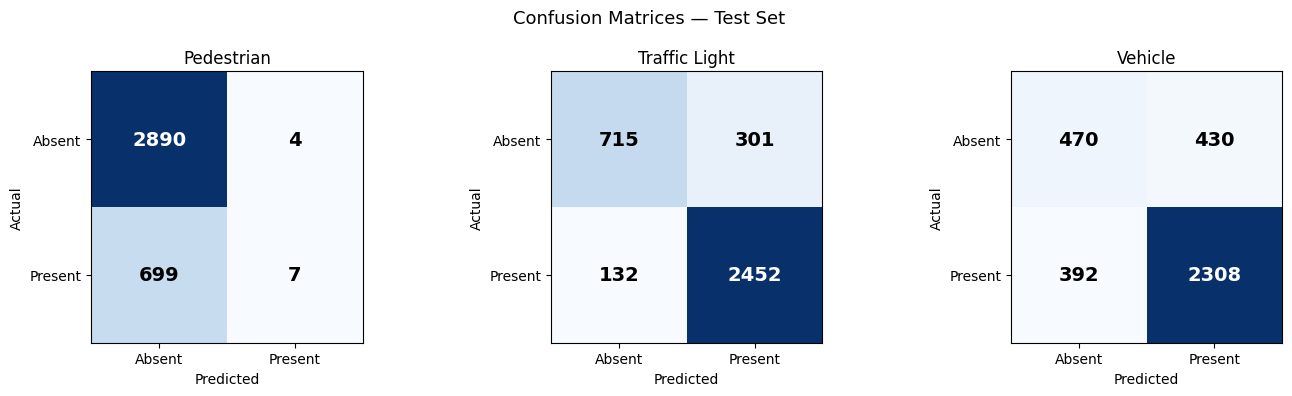

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, label in zip(axes, LABELS):
    cm   = all_cms[label]
    name = label.replace('has_', '').replace('_', ' ').title()

    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_xticks([0, 1]); ax.set_xticklabels(['Absent', 'Present'])
    ax.set_yticks([0, 1]); ax.set_yticklabels(['Absent', 'Present'])

    # Print values inside cells
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center',
                    color='white' if cm[i, j] > cm.max()/2 else 'black',
                    fontsize=14, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13)
plt.tight_layout()
plt.show()